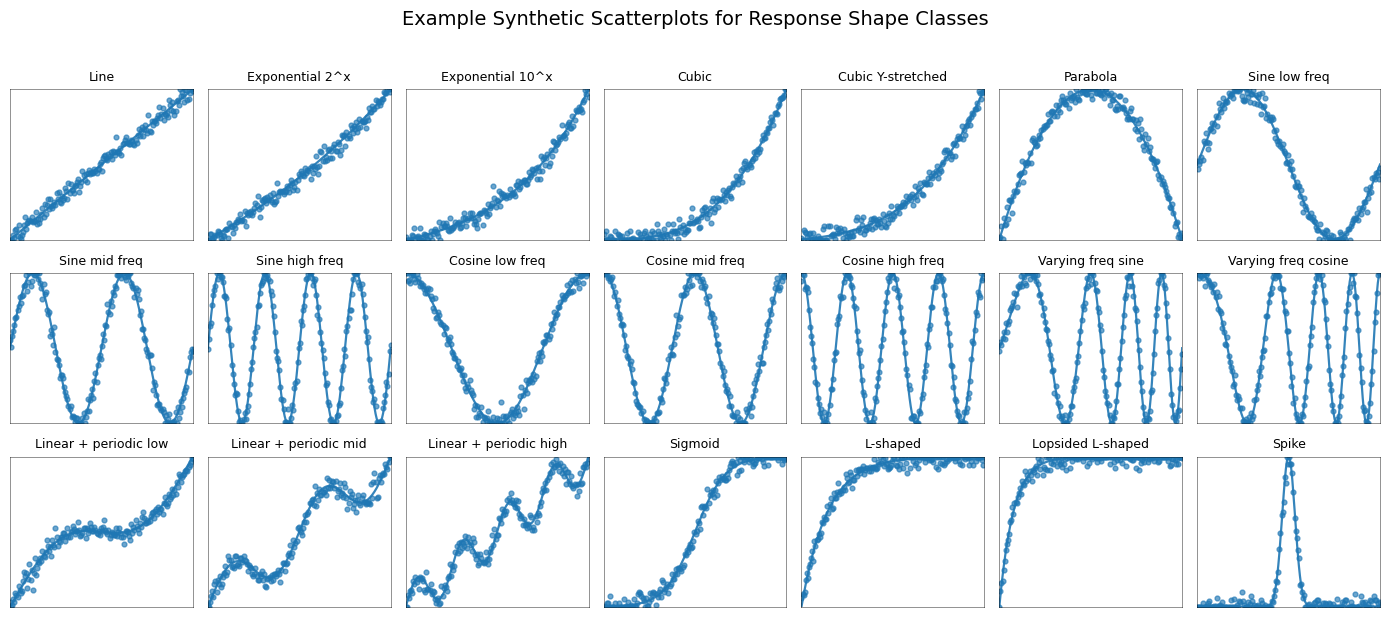

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 0. Basic settings
# ==========================================================

np.random.seed(88)

n = 170
x = np.linspace(0, 1, n)

noise_sd = 0.035
rng = np.random.default_rng(88)


def normalize_y(y):
    """
    Normalize y to [0, 1].
    """
    y = np.asarray(y, dtype=float)
    y_min = np.nanmin(y)
    y_max = np.nanmax(y)

    if y_max - y_min == 0:
        return np.zeros_like(y)

    return (y - y_min) / (y_max - y_min)


def add_noise(y, noise_sd=0.035):
    """
    Add random noise and clip to [0, 1].
    """
    y_noisy = y + rng.normal(0, noise_sd, size=len(y))
    return np.clip(y_noisy, 0, 1)


# ==========================================================
# 1. Define synthetic response functions
# ==========================================================

shape_functions = {

    # ------------------------------------------------------
    # A. Simple monotonic shapes
    # ------------------------------------------------------
    "Line": lambda x: x,

    "Exponential 2^x": lambda x: 2 ** x,

    "Exponential 10^x": lambda x: 10 ** x,

    "Cubic": lambda x: x ** 3,

    "Cubic Y-stretched": lambda x: 0.15 * x + 0.85 * x ** 3,


    # ------------------------------------------------------
    # B. Non-monotonic shapes
    # ------------------------------------------------------
    "Parabola": lambda x: -(x - 0.5) ** 2,

    "Sine low freq": lambda x: np.sin(2 * np.pi * x),

    "Sine mid freq": lambda x: np.sin(4 * np.pi * x),

    "Sine high freq": lambda x: np.sin(8 * np.pi * x),

    "Cosine low freq": lambda x: np.cos(2 * np.pi * x),

    "Cosine mid freq": lambda x: np.cos(4 * np.pi * x),

    "Cosine high freq": lambda x: np.cos(8 * np.pi * x),

    "Varying freq sine": lambda x: np.sin(2 * np.pi * (1 + 3 * x) * x),

    "Varying freq cosine": lambda x: np.cos(2 * np.pi * (1 + 3 * x) * x),


    # ------------------------------------------------------
    # C. Linear + periodic mixed shapes
    # ------------------------------------------------------
    "Linear + periodic low": lambda x: x + 0.18 * np.sin(2 * np.pi * x),

    "Linear + periodic mid": lambda x: x + 0.16 * np.sin(4 * np.pi * x),

    "Linear + periodic high": lambda x: x + 0.13 * np.sin(8 * np.pi * x),


    # ------------------------------------------------------
    # D. Extreme shapes
    # ------------------------------------------------------
    "Sigmoid": lambda x: 1 / (1 + np.exp(-12 * (x - 0.5))),

    "L-shaped": lambda x: 1 - np.exp(-7 * x),

    "Lopsided L-shaped": lambda x: 1 - np.exp(-13 * x),

    "Spike": lambda x: np.exp(-((x - 0.5) ** 2) / (2 * 0.035 ** 2)),
}


# ==========================================================
# 2. Build plotting data
# ==========================================================

plot_items = []

for name, func in shape_functions.items():

    y_clean = func(x)
    y_norm = normalize_y(y_clean)
    y_scatter = add_noise(y_norm, noise_sd=noise_sd)

    plot_items.append({
        "name": name,
        "x": x,
        "y_clean": y_norm,
        "y_scatter": y_scatter,
    })


# ==========================================================
# 3. Plot all example scatterplots
# ==========================================================

n_cols = 7
n_rows = int(np.ceil(len(plot_items) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(n_cols * 2, n_rows * 2),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, item in zip(axes, plot_items):

    ax.scatter(
        item["x"],
        item["y_scatter"],
        s=12,
        alpha=0.65
    )

    ax.plot(
        item["x"],
        item["y_clean"],
        linewidth=1.6,
        alpha=0.9
    )

    ax.set_title(item["name"], fontsize=9)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
        spine.set_alpha(0.5)


# Hide unused axes
for ax in axes[len(plot_items):]:
    ax.axis("off")


fig.suptitle(
    "Example Synthetic Scatterplots for Response Shape Classes",
    fontsize=14,
    y=1.02
)

plt.tight_layout()
plt.show()